In [2]:
source("../R/shared_data.R")
data_features_core <- load_analysis_data()

Warning message:
"le package 'tidyverse' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'tibble' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'readr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'purrr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'stringr' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'forcats' a été compilé avec la version R 4.4.3"
Warning message:
"le package 'lubridate' a été compilé avec la version R 4.4.3"


In [3]:
var_quanti <- names(data_features_core)[sapply(data_features_core, is.numeric)]
var_quali  <- names(data_features_core)[sapply(data_features_core, is.factor)]

# Vérifier
var_quanti
var_quali


[1] "Capacité.de.l.établissement.par.formation"                                             
 [2] "Effectif.total.admis.2phases"                                                          
 [3] "Effectif.total.candidats.2phases"                                                      
 [4] "Pourcentage.boursiers.candidats"                                                       
 [5] "Pourcentage.boursiers.admis"                                                           
 [6] "pct_filles_admises"                                                                    
 [7] "pct_garcons_admis"                                                                     
 [8] "pression_candidature"                                                                  
 [9] "taux_admission"                                                                        
[10] "taux_remplissage"                                                                      
[11] "taux_acces_num"                                                                        
[12] "part_mention_ab"                                                                       
[13] "part_mention_b"                                                                        
[14] "part_mention_tb"                                                                       
[15] "part_mention_tb_fel"                                                                   
[16] "part_mention_haute"                                                                    
[17] "score_mention"                                                                         
[18] "X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies."
[19] "X..d.admis.néo.bacheliers.généraux"                                                    
[20] "X..d.admis.néo.bacheliers.technologiques"                                              
[21] "X..d.admis.néo.bacheliers.professionnels"                                              
[22] "log_candidats"                                                                         
[23] "log_admis"                                                                             
[24] "log_capacite"

[1] "Établissement"                     "Statut.Etablissement"             
[3] "Filière.de.formation"              "Filière.de.formation.très.agrégée"
[5] "Région.de.l.établissement"         "Académie.de.l.établissement"      
[7] "Sélectivité"

# Analyse uni-dimensionnelle des variables

Autre formation               BTS               BUT              CPGE 
             1815              5351               820               986 
Ecole d'Ingénieur Ecole de Commerce              EFTS              IFSI 
              585               256               243               344 
          Licence       Licence_Las              PASS 
             3052               513               287

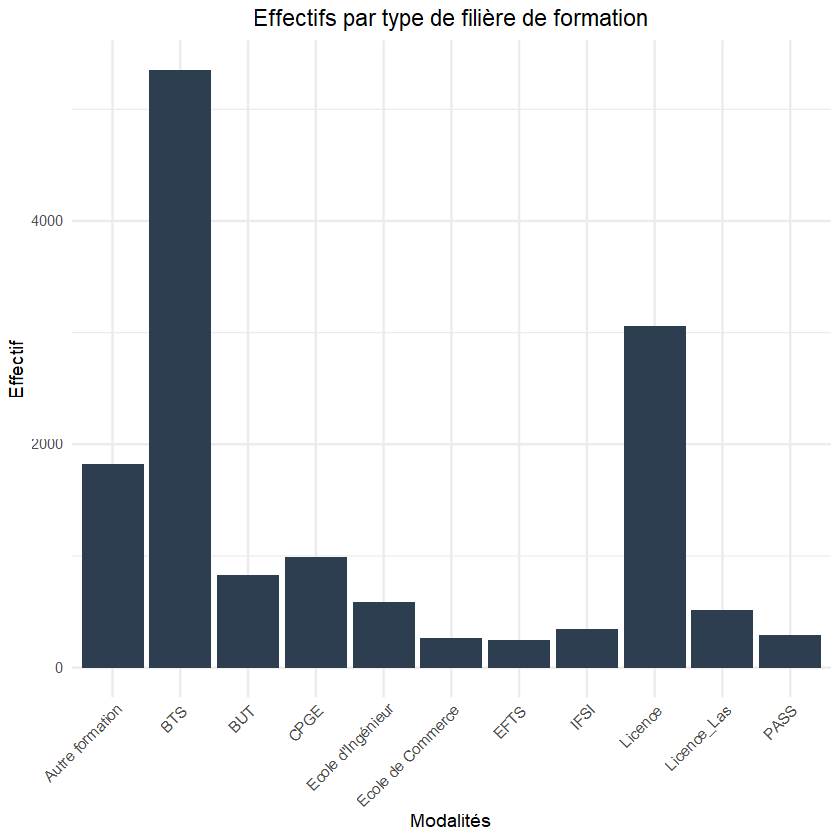

In [4]:
###Effectif par formation
summary(data_features_core$`Filière.de.formation.très.agrégée`)
library(ggplot2)

ggplot(data_features_core, aes(x = `Filière.de.formation.très.agrégée`)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par type de filière de formation",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

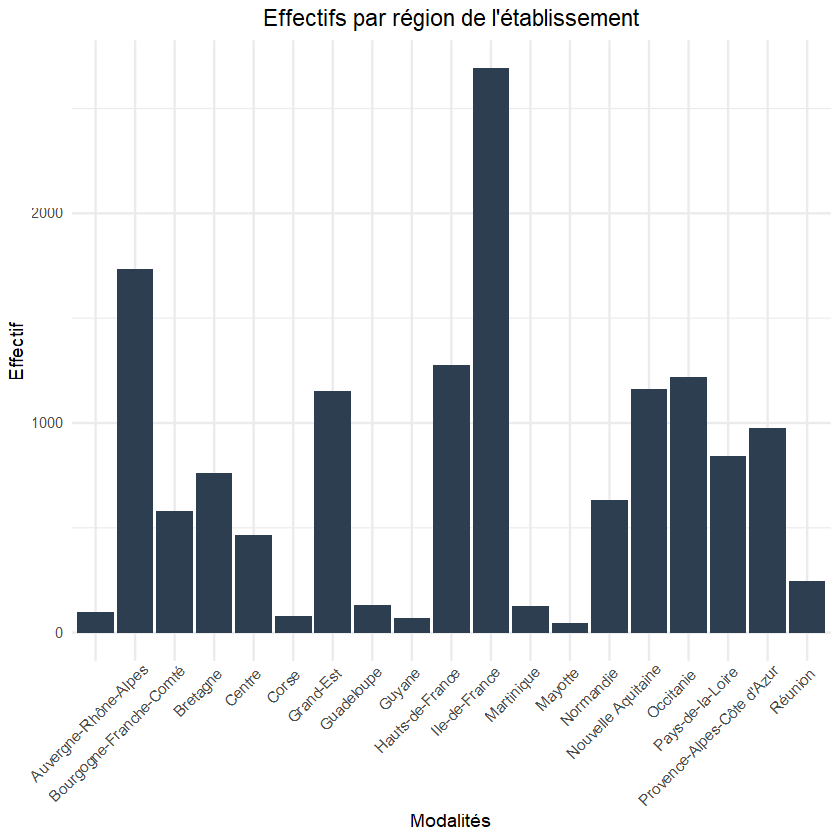

In [5]:
###Effectifs par région
ggplot(data_features_core, aes(x = Région.de.l.établissement)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par région de l'établissement",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

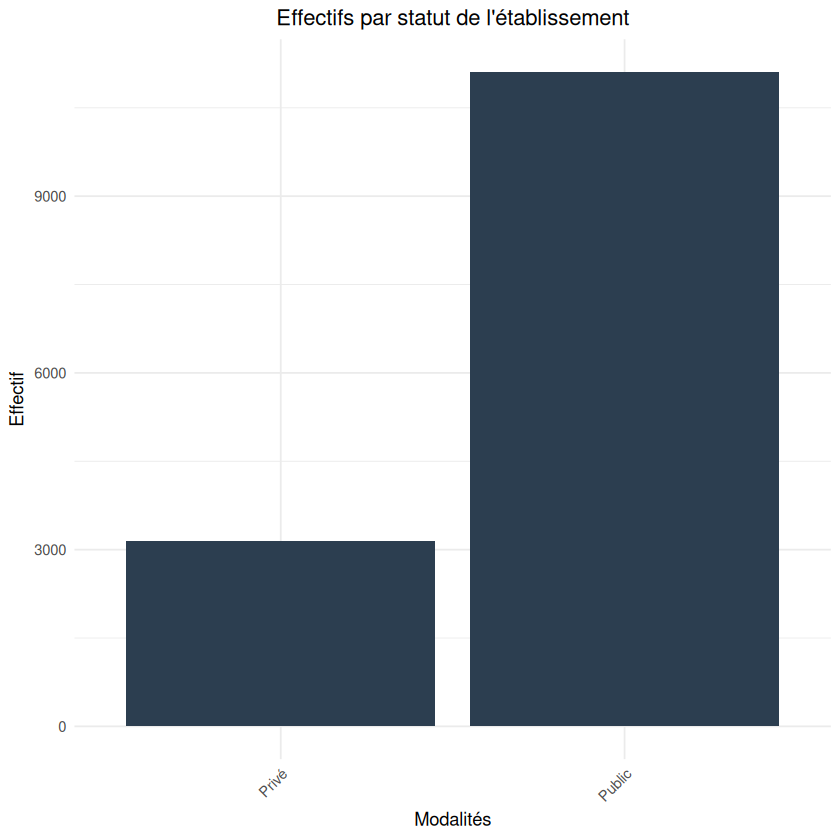

In [22]:
ggplot(data_features_core, aes(x = Statut.Etablissement)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par statut de l'établissement",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

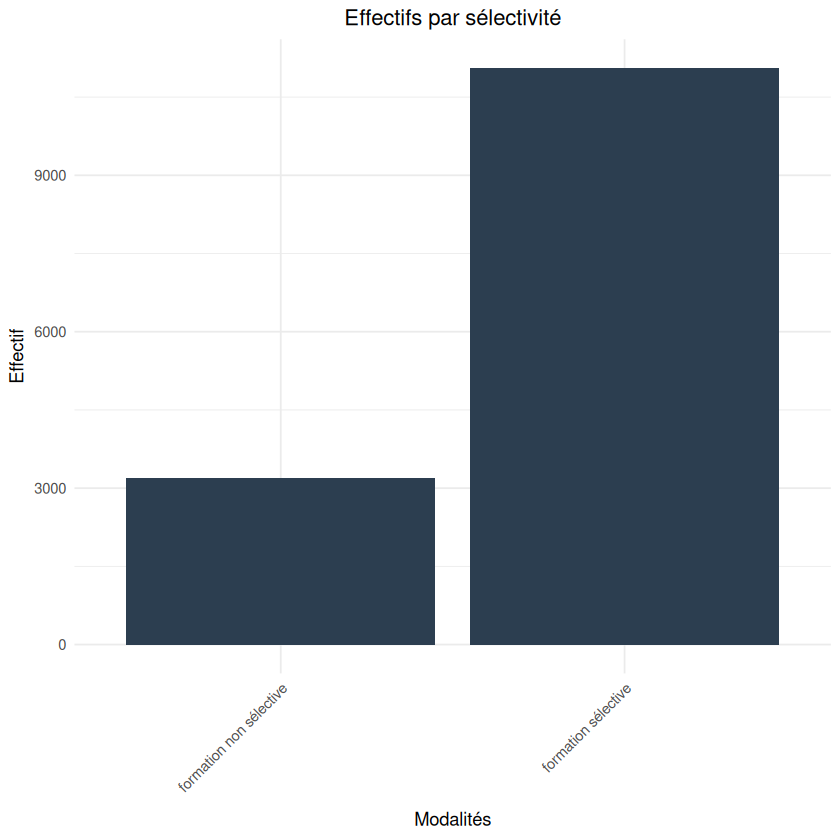

In [23]:
ggplot(data_features_core, aes(x = Sélectivité)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par sélectivité",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

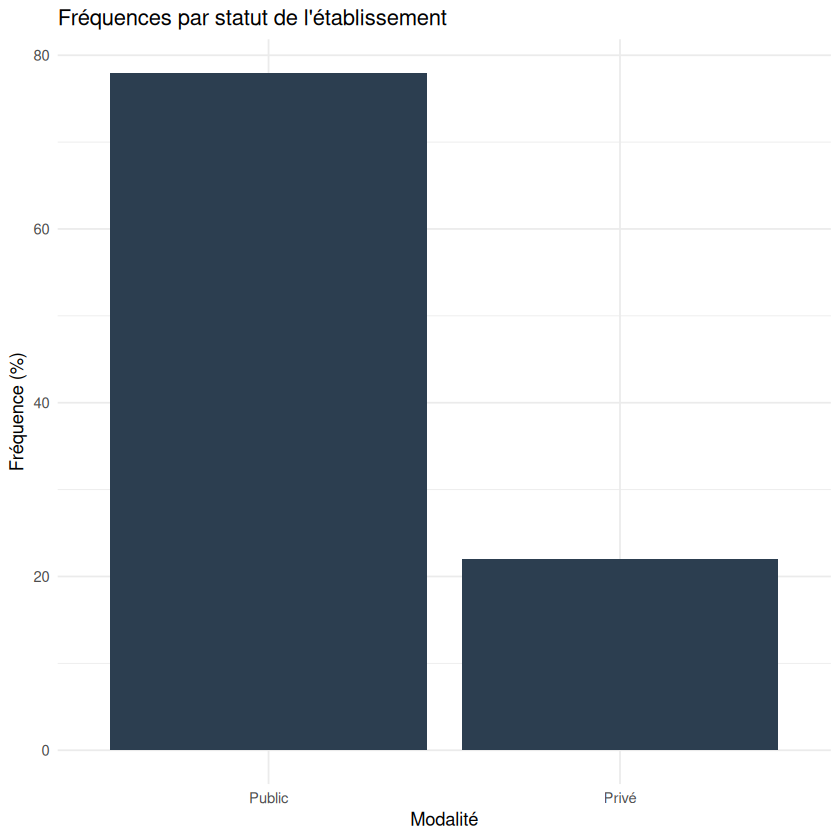

In [26]:
data_features_core %>%
  count(Statut.Etablissement) %>%
  mutate(freq_pct = n / sum(n) * 100) %>%
  ggplot(aes(x = reorder(Statut.Etablissement, -freq_pct), y = freq_pct)) +
  geom_bar( stat = "identity", fill = "#2C3E50") +
  labs(title= "Fréquences par statut de l'établissement",x = "Modalité", y = "Fréquence (%)") +
  theme_minimal()

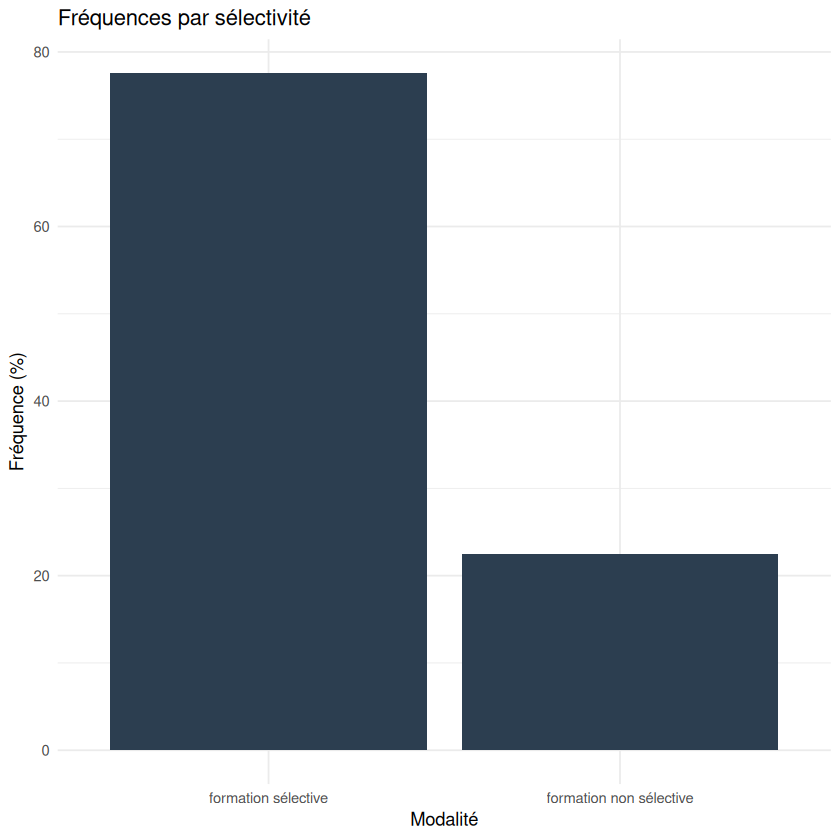

In [27]:
data_features_core %>%
  count(Sélectivité) %>%
  mutate(freq_pct = n / sum(n) * 100) %>%
  ggplot(aes(x = reorder(Sélectivité, -freq_pct), y = freq_pct)) +
  geom_bar( stat = "identity", fill = "#2C3E50") +
  labs(title= "Fréquences par sélectivité",x = "Modalité", y = "Fréquence (%)") +
  theme_minimal()

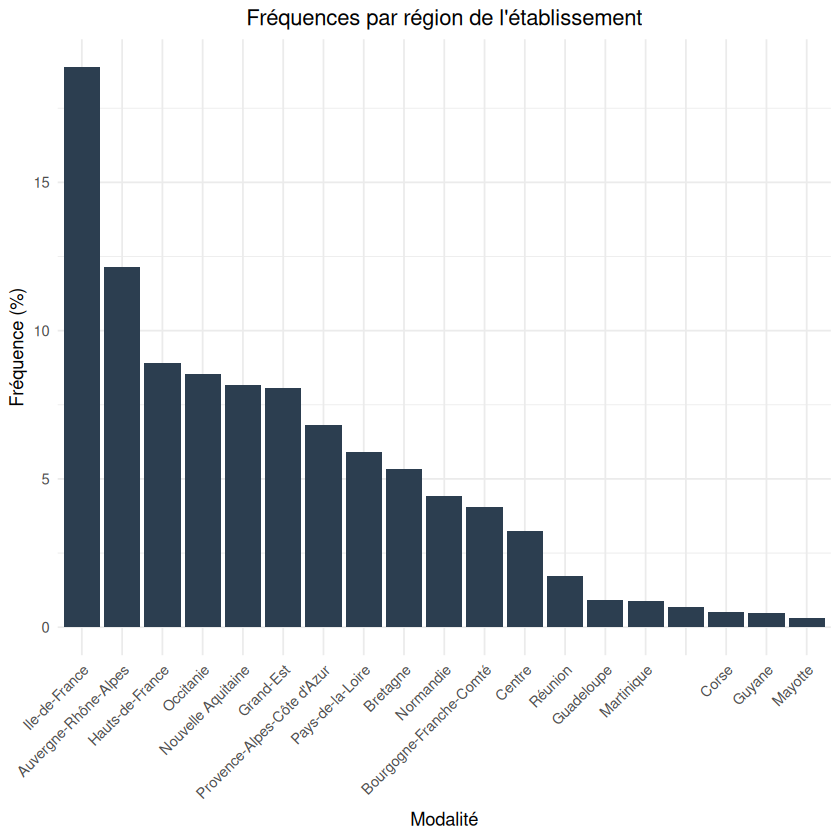

In [29]:
data_features_core %>%
  count(Région.de.l.établissement) %>%
  mutate(freq_pct = n / sum(n) * 100) %>%
  ggplot(aes(x = reorder(Région.de.l.établissement, -freq_pct), y = freq_pct)) +
  geom_bar( stat = "identity", fill = "#2C3E50") +
  labs(title= "Fréquences par région de l'établissement",x = "Modalité", y = "Fréquence (%)") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

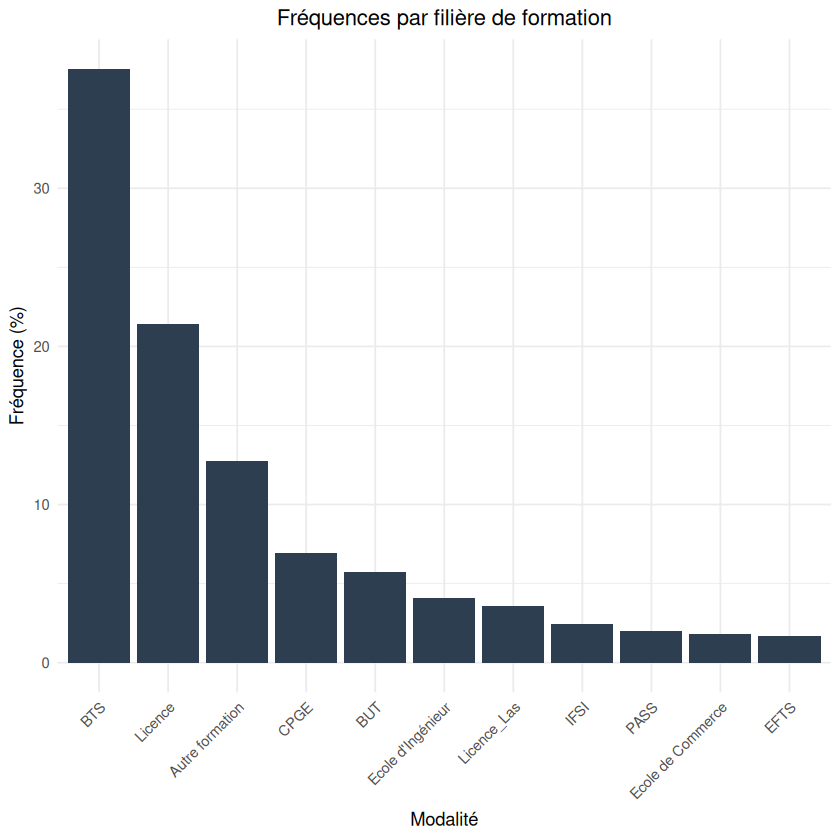

In [30]:
data_features_core %>%
  count(Filière.de.formation.très.agrégée) %>%
  mutate(freq_pct = n / sum(n) * 100) %>%
  ggplot(aes(x = reorder(Filière.de.formation.très.agrégée, -freq_pct), y = freq_pct)) +
  geom_bar( stat = "identity", fill = "#2C3E50") +
  labs(title= "Fréquences par filière de formation",x = "Modalité", y = "Fréquence (%)") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

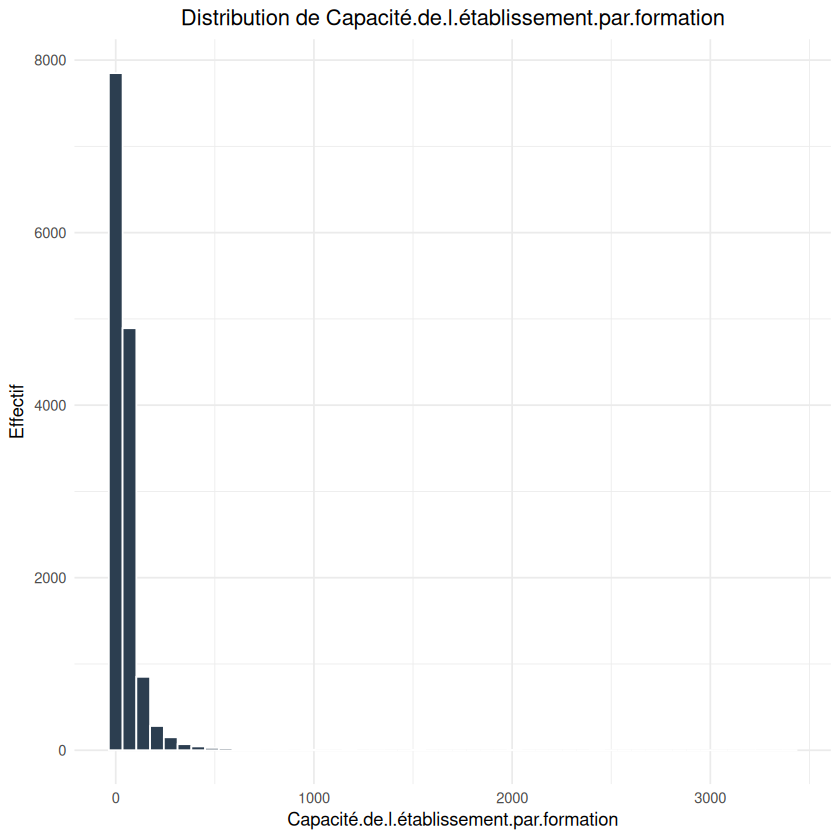

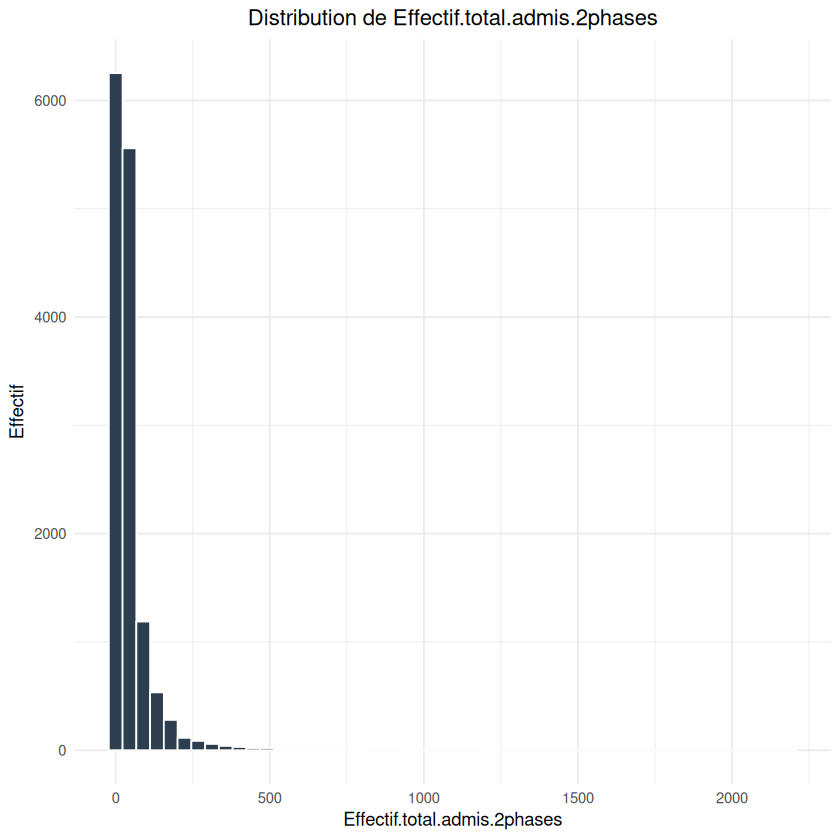

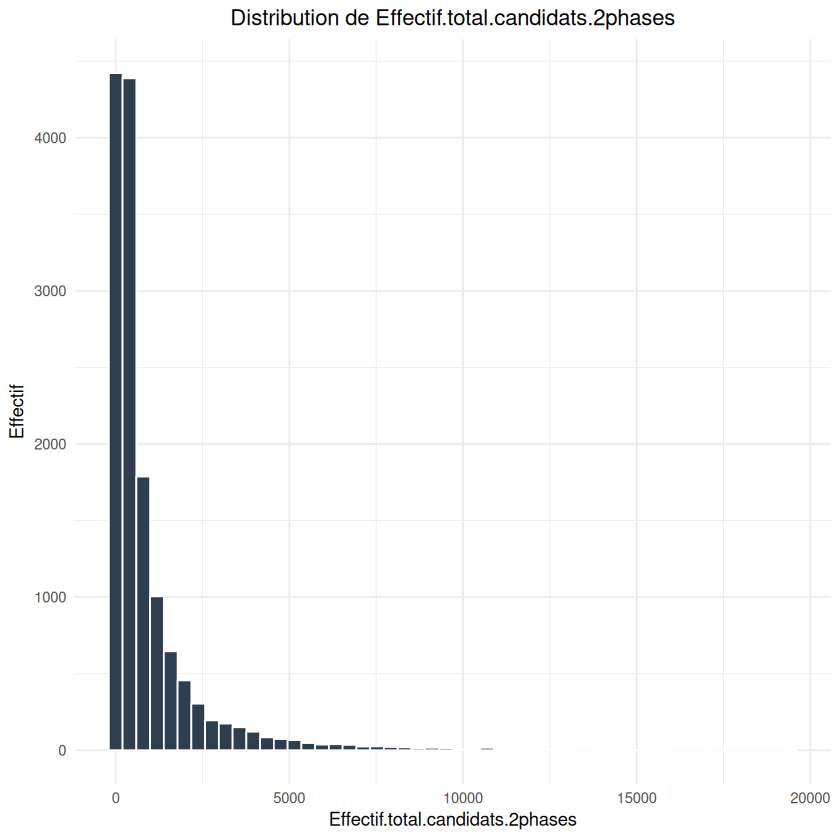

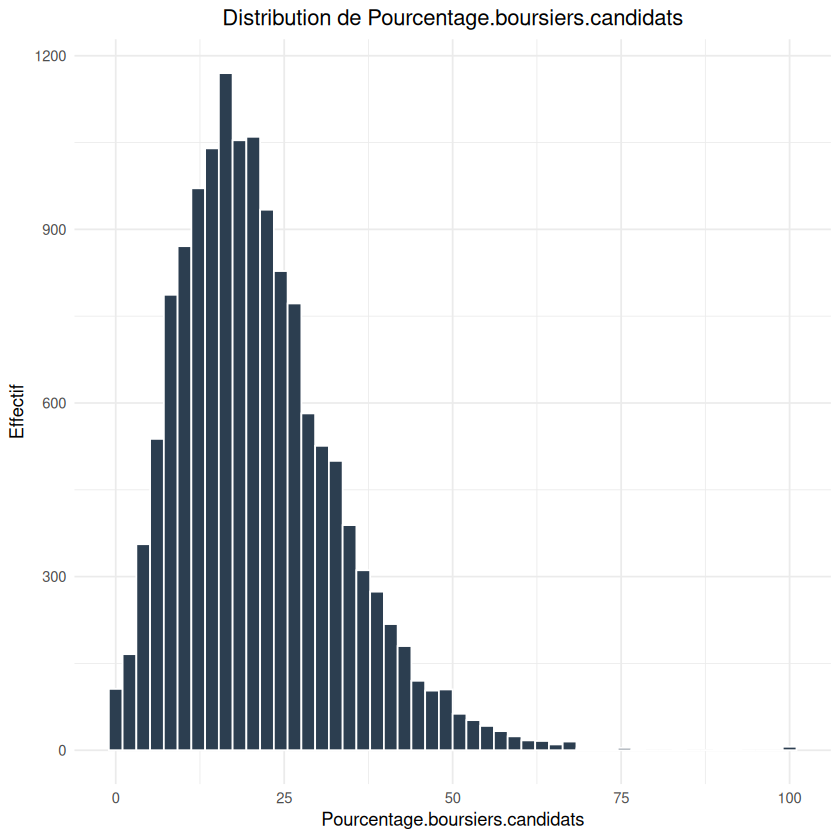

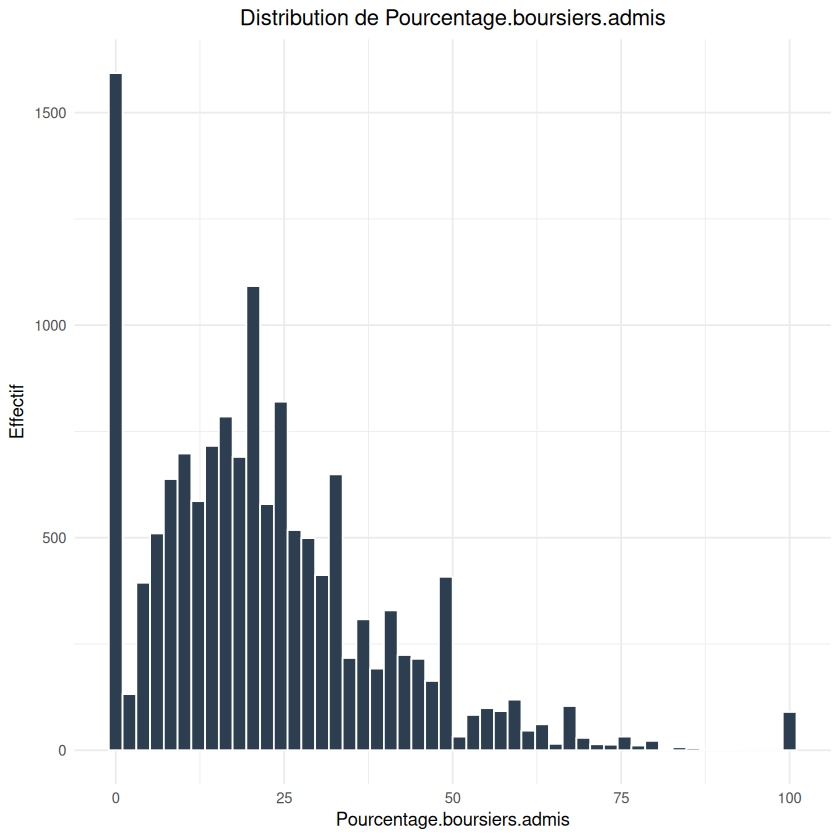

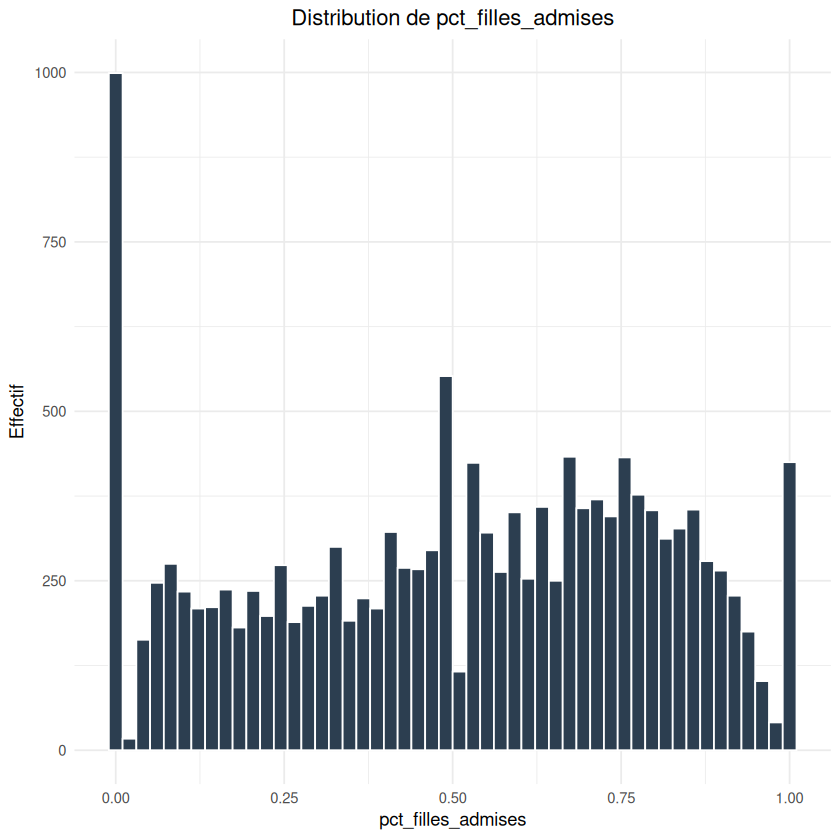

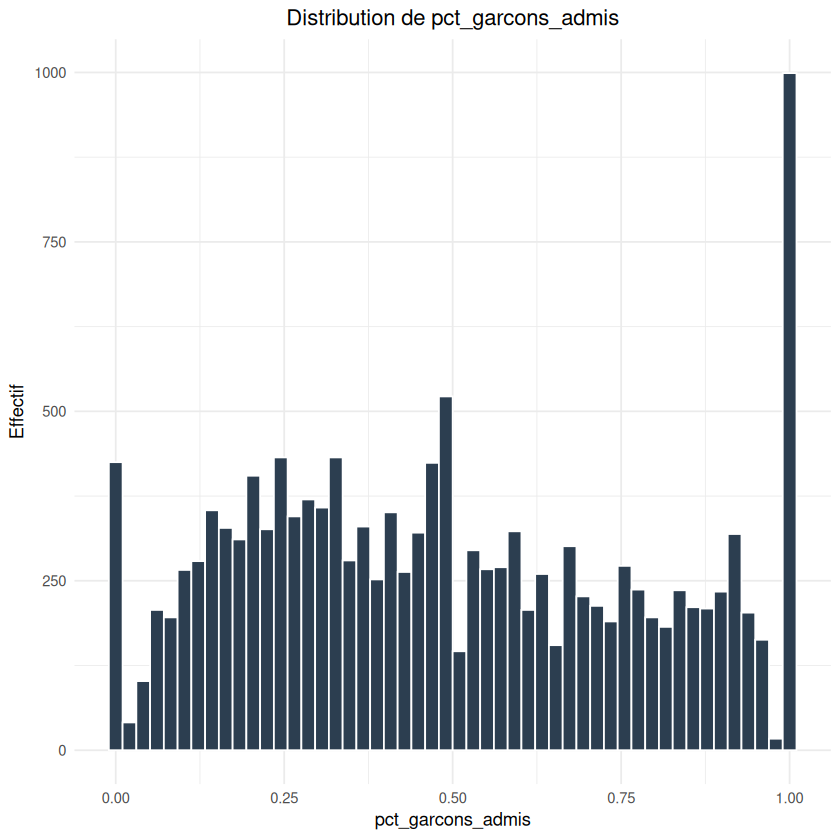

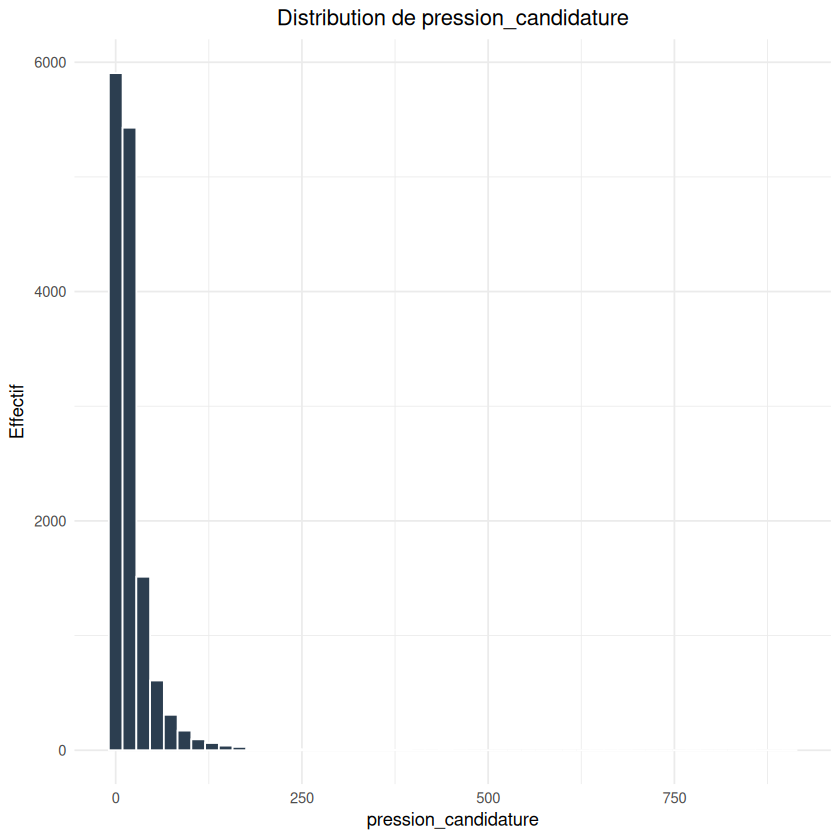

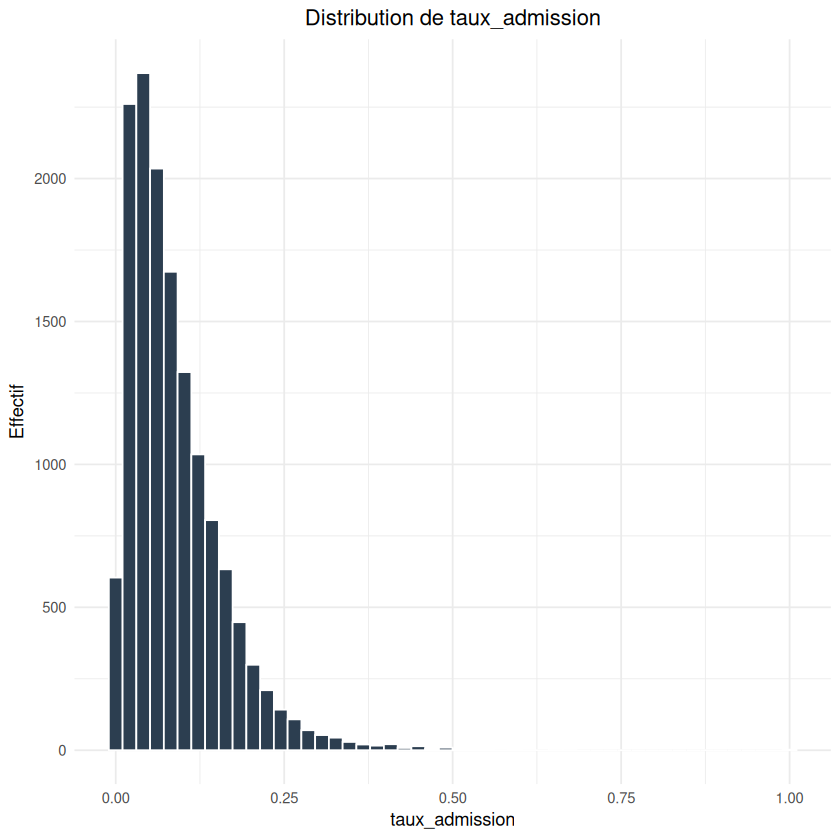

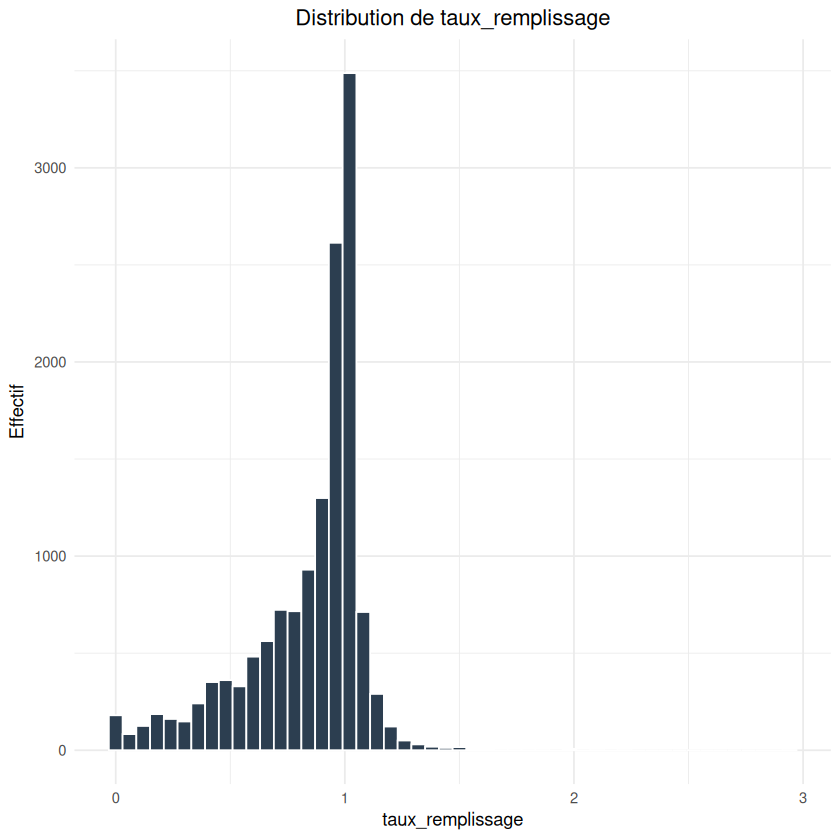

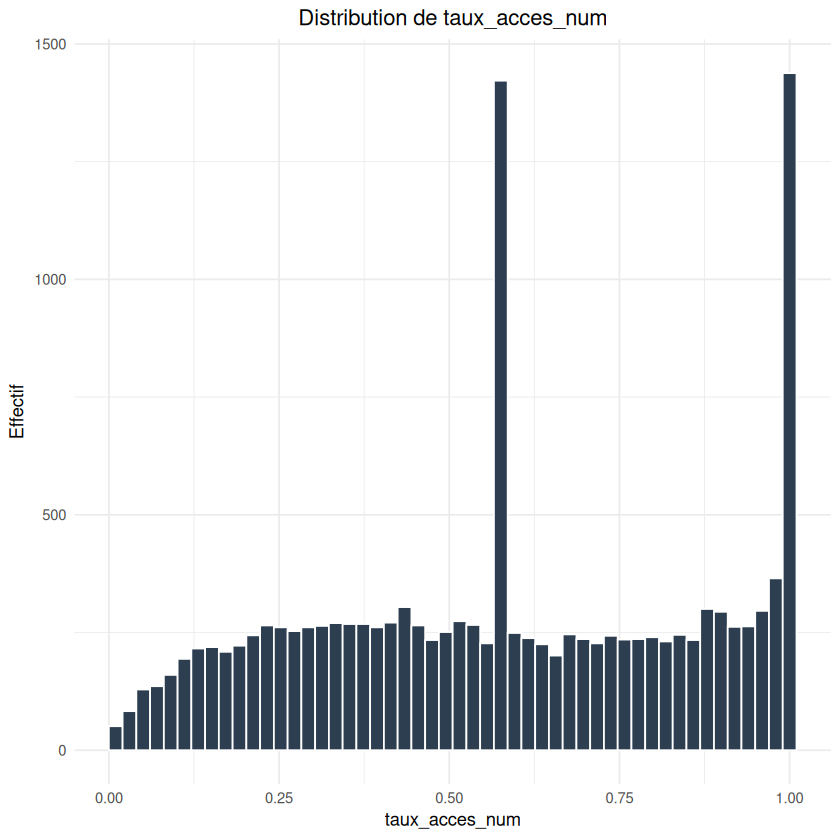

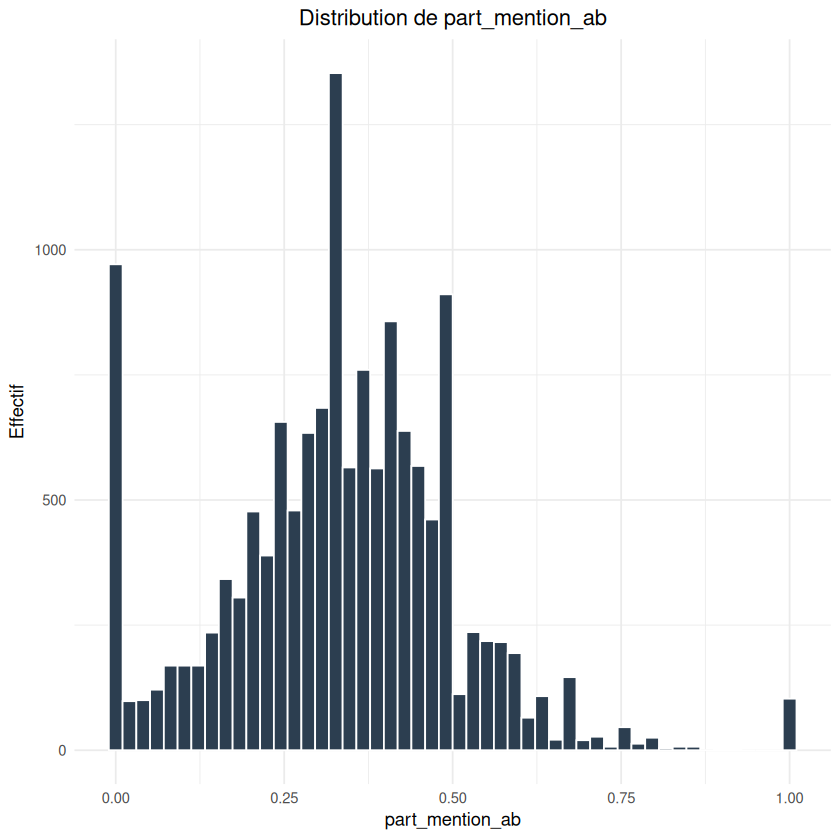

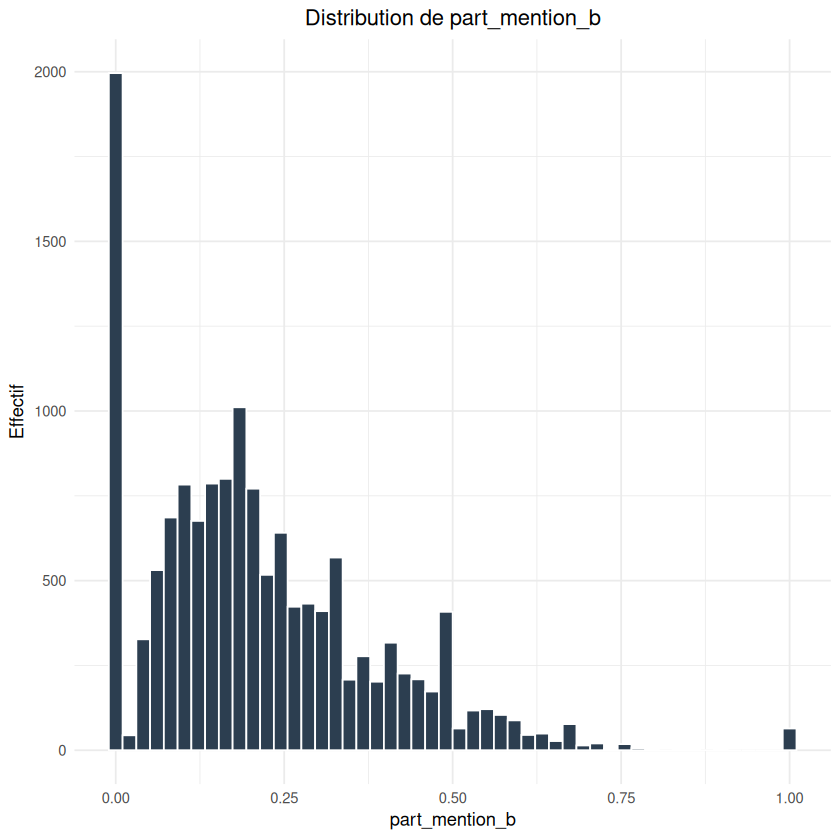

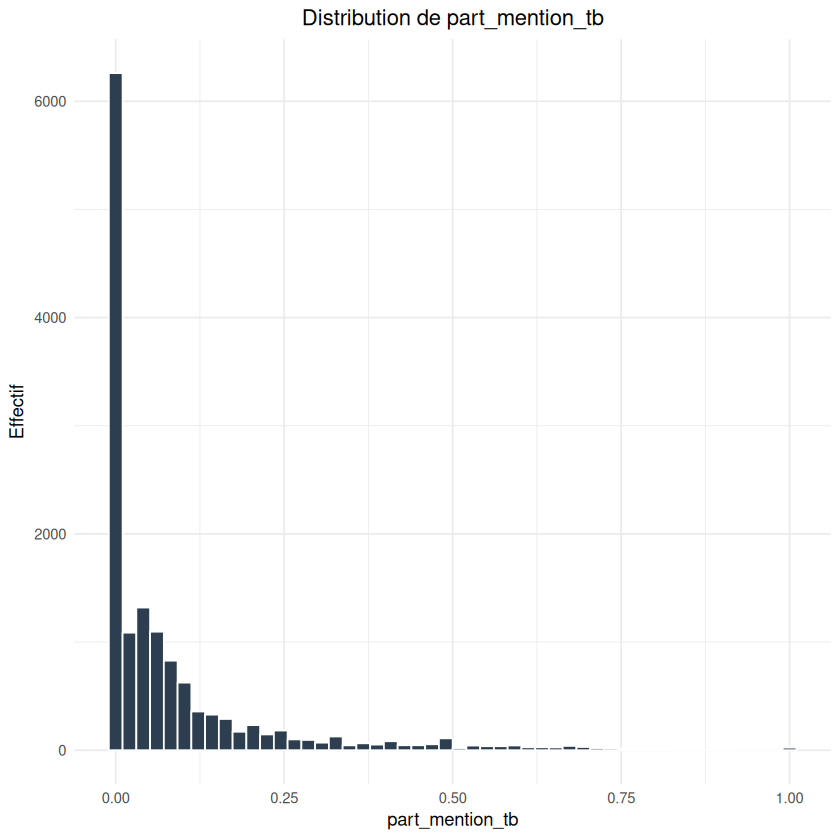

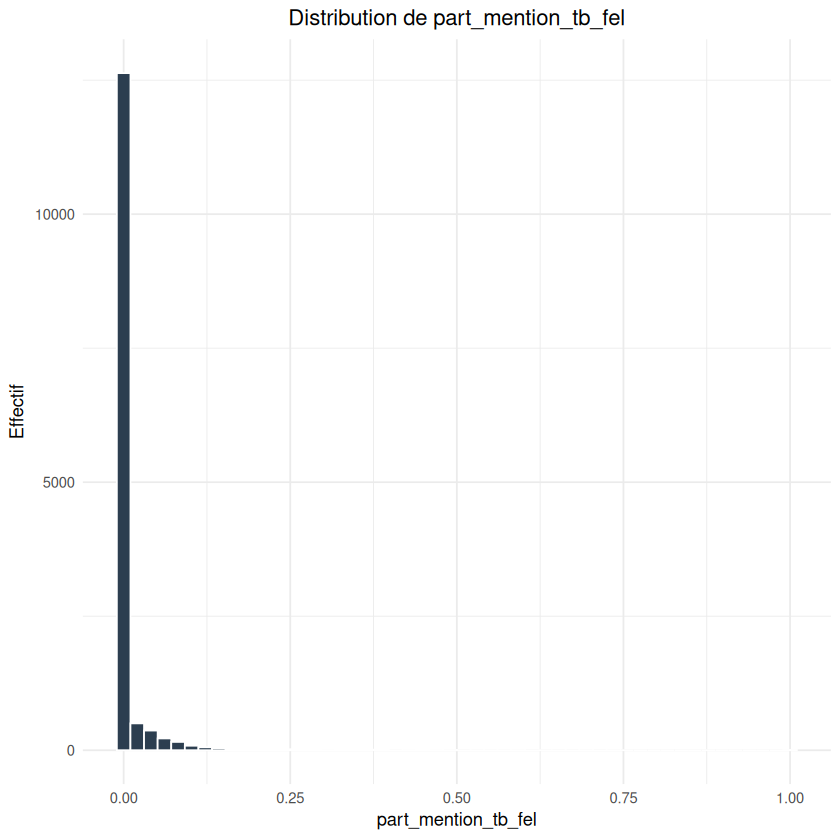

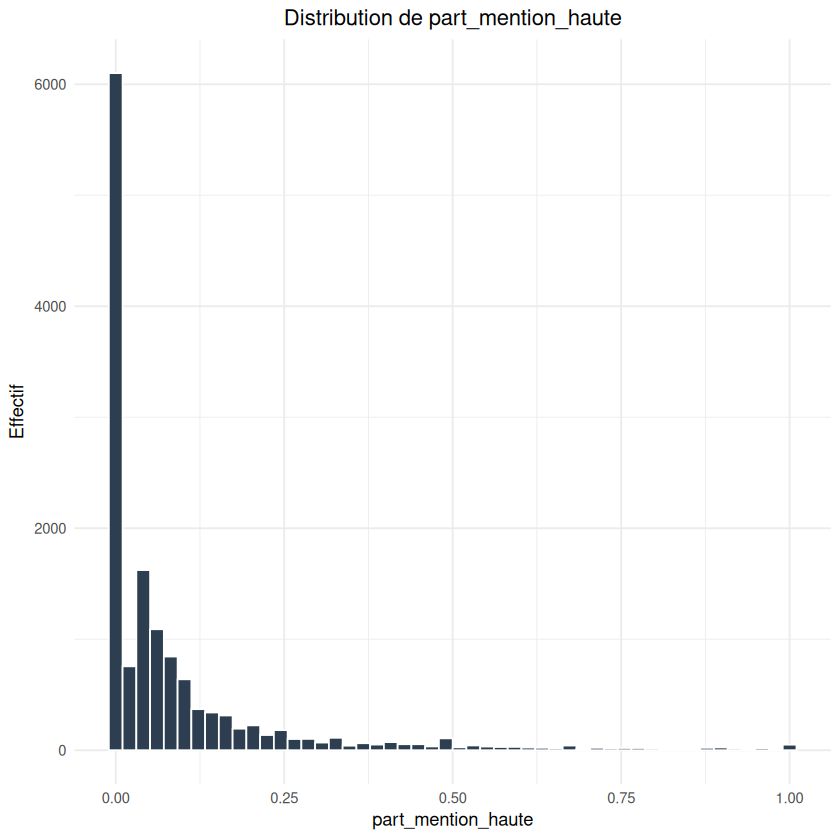

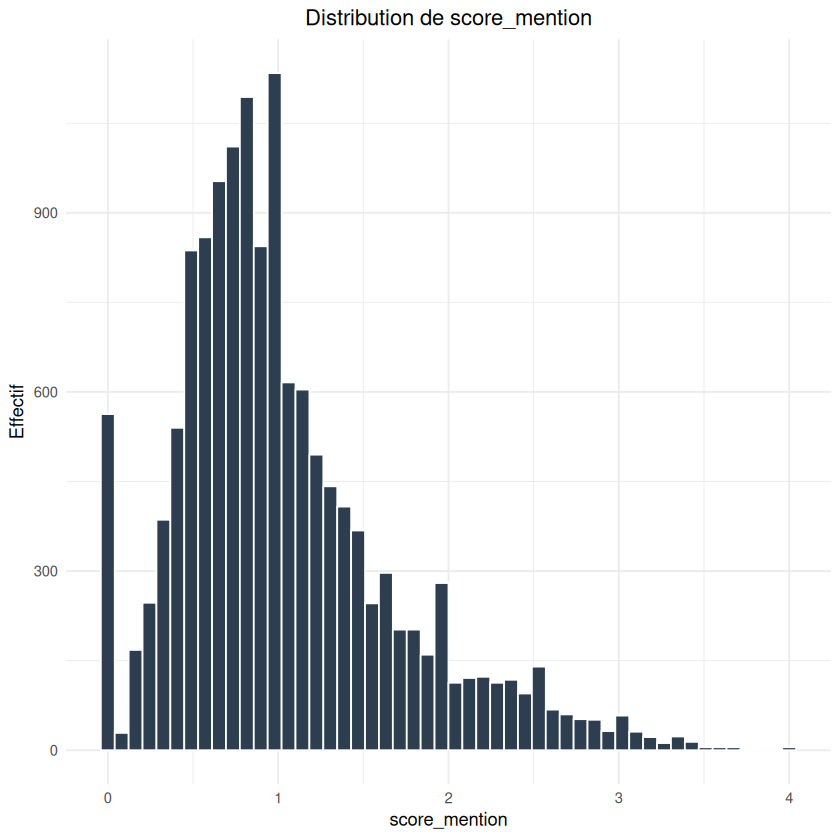

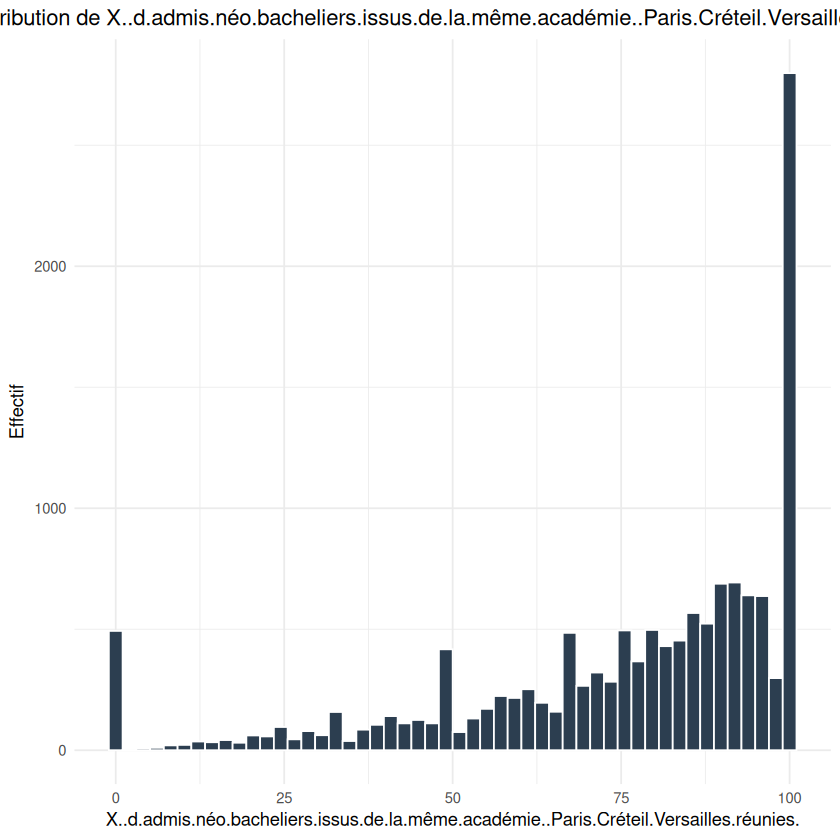

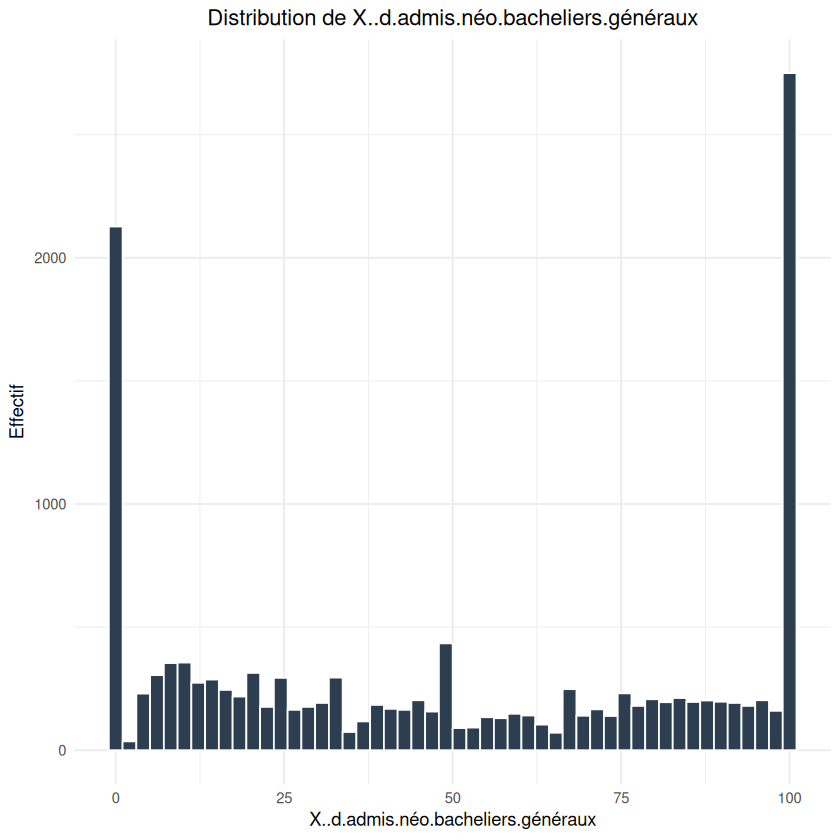

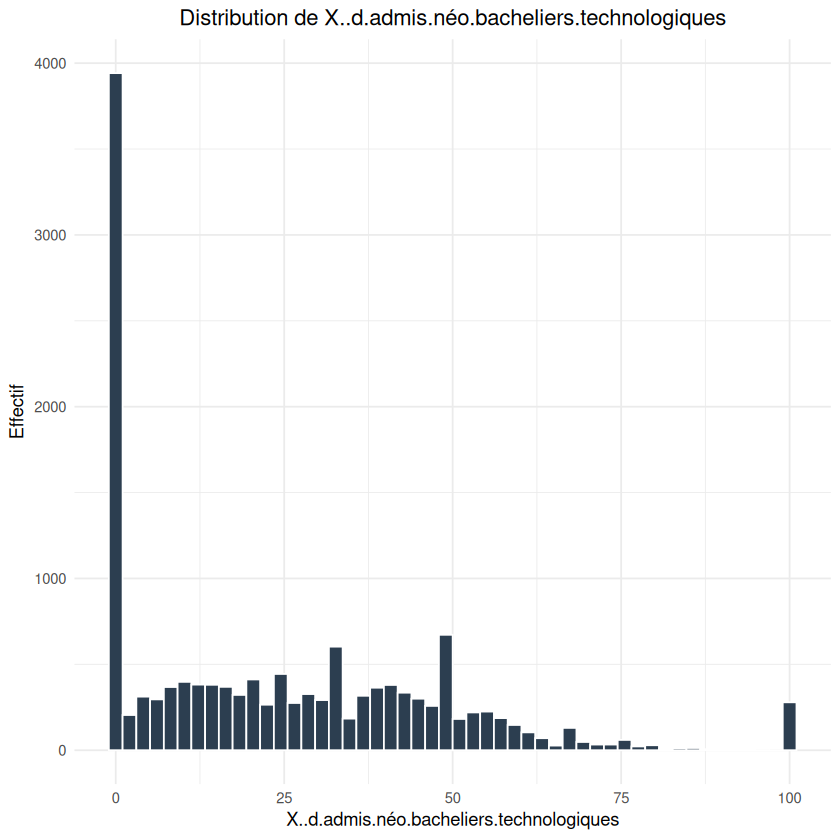

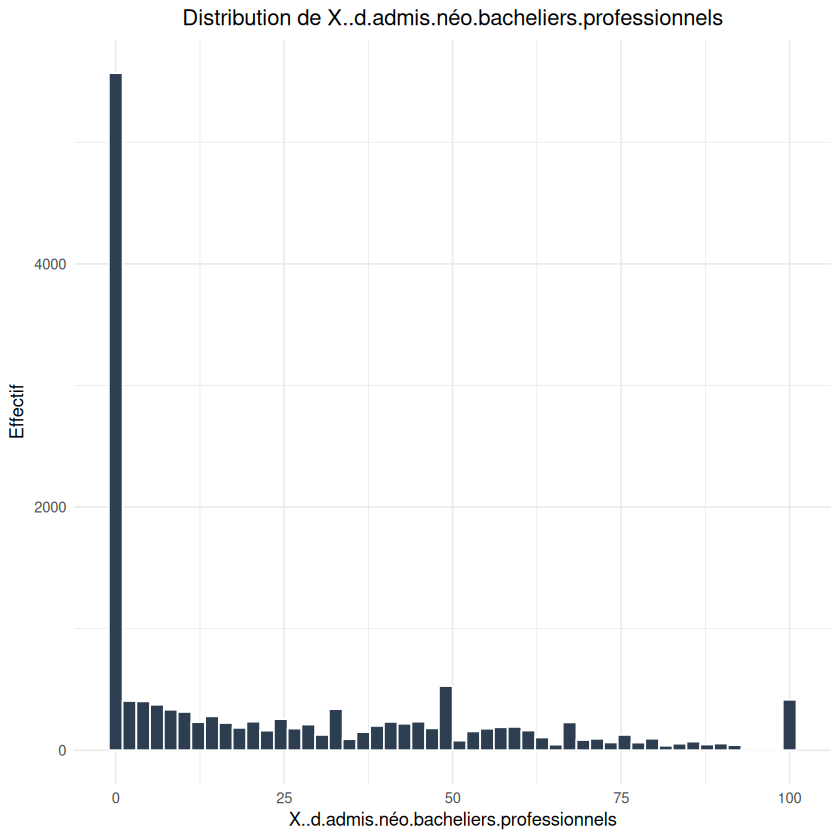

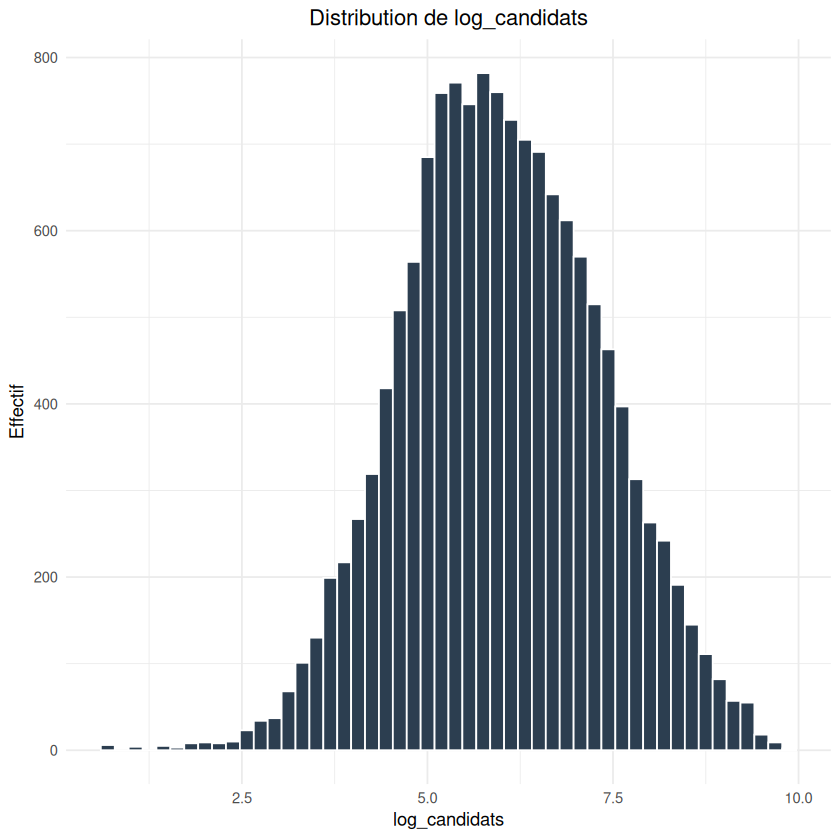

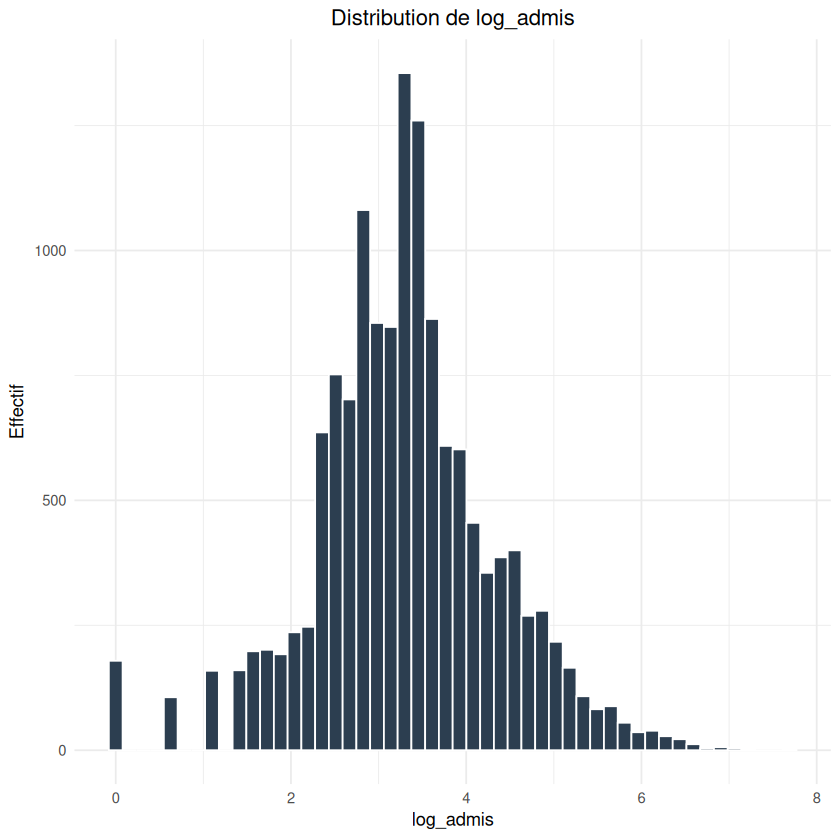

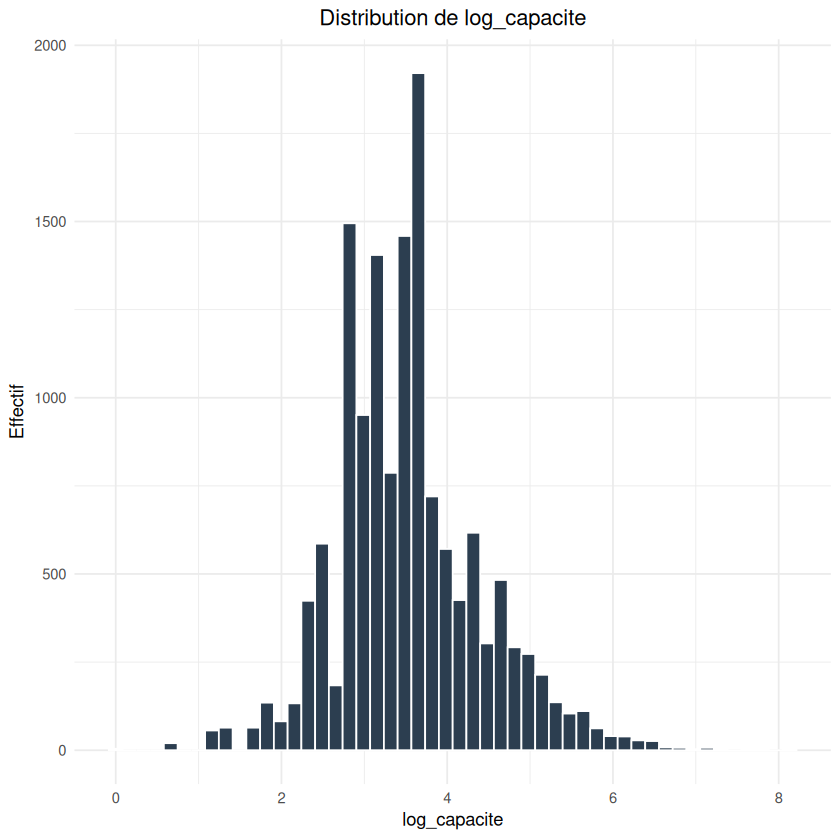

In [32]:
for (var in var_quanti) {
  p <- ggplot(data_features_core, aes(x = .data[[var]])) +
    geom_histogram(fill = "#2C3E50", color = "white", bins = 50) +
    labs(
      title = paste("Distribution de", var),
      x = var,
      y = "Effectif"
    ) +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5))
  
  print(p)  # indispensable dans une boucle for
}

1. Analyse des effectifs par type de formation: 

L’examen de la distribution des effectifs révèle une forte concentration des étudiants au sein des cycles BTS et Licence. 
2. Répartition géographique et attractivité régionale

Une analyse spatiale met en évidence une structure territoriale polarisée : l’Île-de-France et l’Auvergne-Rhône-Alpes s’affirment comme les principaux pôles d’accueil, concentrant les volumes d’étudiants les plus importants à l'échelle nationale.

3. Dualité du secteur d'enseignement (Public vs Privé)

En termes de capacité d'accueil, le secteur public demeure prépondérant face au secteur privé. 

4. Modalités d'accès et sélectivité

L'analyse des conditions d'admission souligne un marché de la formation marqué par la sélectivité. Une large majorité des cursus observés impose des critères d’accès restreints.

5. Indicateurs de mixité sociale (Taux de boursiers)

L'étude du profil social des étudiants montre une relative homogénéité : les formations accueillent, en moyenne, entre 15% et 20% de boursiers.